In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
from pickle import dump ,load
from scipy import stats
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Exploratory Data Analysis (EDA)

Initial Data Understanding 

Data loading and Inspection

Data Types

Missing Values

Duplicates

In [2]:
df = pd.read_csv(r"C:\bank customer churn\bank customer churn dataset.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.rename(columns={
    'HasCrCard': 'Has credit card',
    'IsActiveMember': 'Is Active Member',
    'CreditScore': 'Credit Score',
    'NumOfProducts': 'Number Of Products',
    'EstimatedSalary': 'Estimated Salary',
    'Exited': 'Churned'
})

In [10]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], inplace=True, axis=1)

# Basic Statistical Overview

Summary Statistical : describe()

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Credit Score,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
Number Of Products,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
Has credit card,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
Is Active Member,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
Estimated Salary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Churned,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


# Distribution of Number of Products

Number Of Products
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


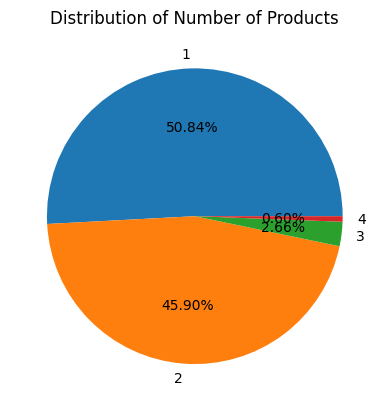

In [15]:
counts = df['Number Of Products'].value_counts()

# Print values
print(counts)

# Plot pie chart
counts.plot.pie(
    autopct='%0.2f%%',
    title='Distribution of Number of Products'
)

plt.ylabel('')
plt.show()

# Key Insights

A majority of customers (over 96%) hold either 1 or 2 products, indicating that most customers have limited engagement with the bank’s offerings.

Only a very small fraction (~3%) of customers use 3 or more products, suggesting low cross-selling effectiveness.

The sharp drop from 2 products to 3 products highlights a potential opportunity for the bank to promote additional products to existing customers.

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


C:\Users\FAUZAN\AppData\Local\Temp\ipykernel_1944\4210854395.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Geography', data=df, palette=['green','blue','yellow'])


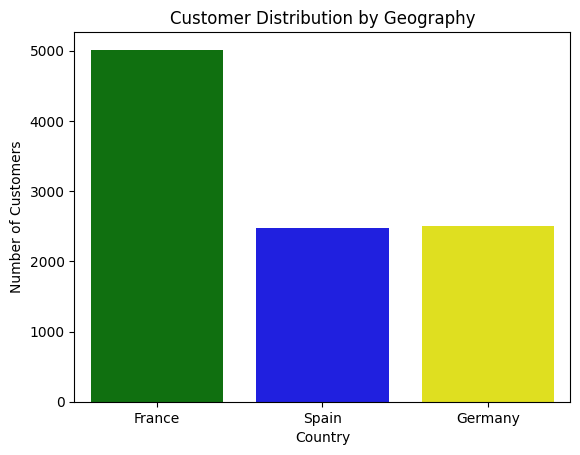

In [16]:
counts = df['Geography'].value_counts()

# Print counts
print(counts)

# Plot
sns.countplot(x='Geography', data=df, palette=['green','blue','yellow'])
plt.title('Customer Distribution by Geography')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.show()

# Key Insights: Customer Distribution by Geography

France has the highest number of customers (~50%), contributing nearly half of the dataset.

Germany and Spain have almost equal representation (~25% each), indicating a balanced distribution between these two regions.

The dataset is slightly skewed towards France, which may influence model predictions if geography impacts churn behavior.

# Distribution of Credit Card Holders

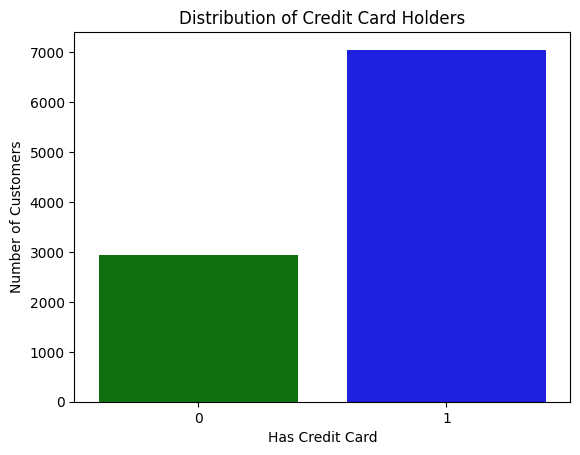

In [18]:
sns.countplot(
    x='Has credit card',
    data=df,
    hue='Has credit card',
    palette=['green','blue'],
    legend=False
)
plt.title('Distribution of Credit Card Holders')
plt.xlabel('Has Credit Card')
plt.ylabel('Number of Customers')
plt.show()

# Key Insights: Credit Card Distribution

A majority of customers (~70%) have a credit card, indicating strong adoption of this service.

Around 30% of customers do not have a credit card, representing a potential segment for targeted marketing.

Since most customers already own a credit card, this feature alone may have limited impact on distinguishing churn behavior.

# Distribution of Active Members

Is Active Member
1    5151
0    4849
Name: count, dtype: int64


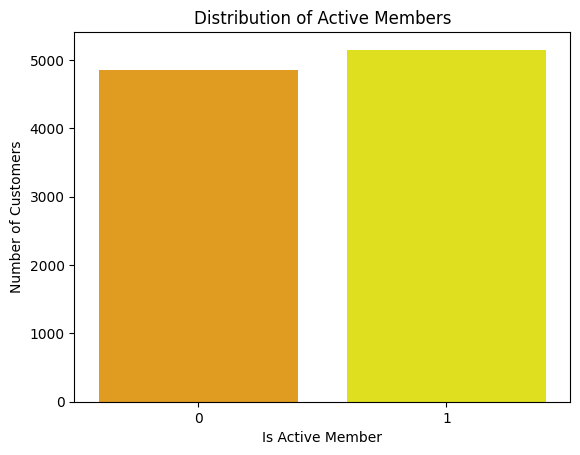

In [23]:
counts = df['Is Active Member'].value_counts()

# Print counts
print(counts)

# Plot
sns.countplot(
    x='Is Active Member',
    data=df,
    hue='Is Active Member',
    palette=['orange','yellow'],
    legend=False
)
plt.title('Distribution of Active Members')
plt.xlabel('Is Active Member')
plt.ylabel('Number of Customers')
plt.show()

# Key Insights: Active Member Distribution

Customers are almost evenly split between active (~51.5%) and inactive (~48.5%) members.

A slightly higher number of active customers indicates moderate engagement with the bank’s services.

The near-balanced distribution suggests that customer activity level could be a strong factor in predicting churn, especially when compared with churn behavior.

# Distribution by Gender

Gender
Male      5457
Female    4543
Name: count, dtype: int64


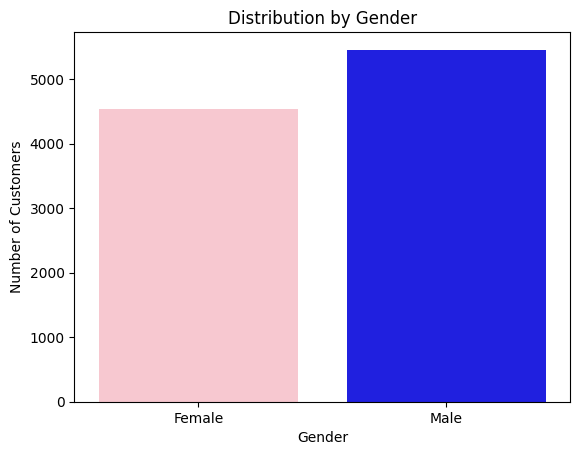

In [24]:
counts = df['Gender'].value_counts()

# Print counts
print(counts)

# Plot
sns.countplot(
    x='Gender',
    data=df,
    hue='Gender',
    palette=['pink','blue'],
    legend=False
)
plt.title('Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

# Key Insights: Gender Distribution

The dataset has a slight majority of male customers (~54.6%) compared to female customers (~45.4%).

The distribution is fairly balanced, indicating no strong gender bias in the dataset.

Since the difference is not large, gender alone may have limited impact on predicting churn, but it can still be useful when combined with other features.

# Customer Churn Distribution

Churned
0    7963
1    2037
Name: count, dtype: int64


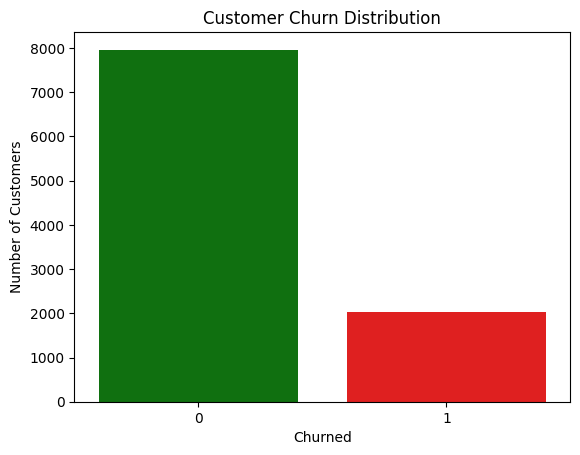

In [25]:
counts = df['Churned'].value_counts()

# Print counts
print(counts)

# Plot
sns.countplot(
    x='Churned',
    data=df,
    hue='Churned',
    palette=['green','red'],
    legend=False
)
plt.title('Customer Churn Distribution')
plt.xlabel('Churned')
plt.ylabel('Number of Customers')
plt.show()

# Key Insights: Customer Churn Distribution

A large majority of customers (~79.6%) have not churned, while only ~20.4% have churned.

This indicates a class imbalance, where non-churned customers significantly outnumber churned ones.

The imbalance suggests that special care (like using appropriate evaluation metrics or class balancing techniques) is needed while building predictive models.

# Distribution of Variables

Numerical Features (KDE)

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64

Zero Balance Count:
3617


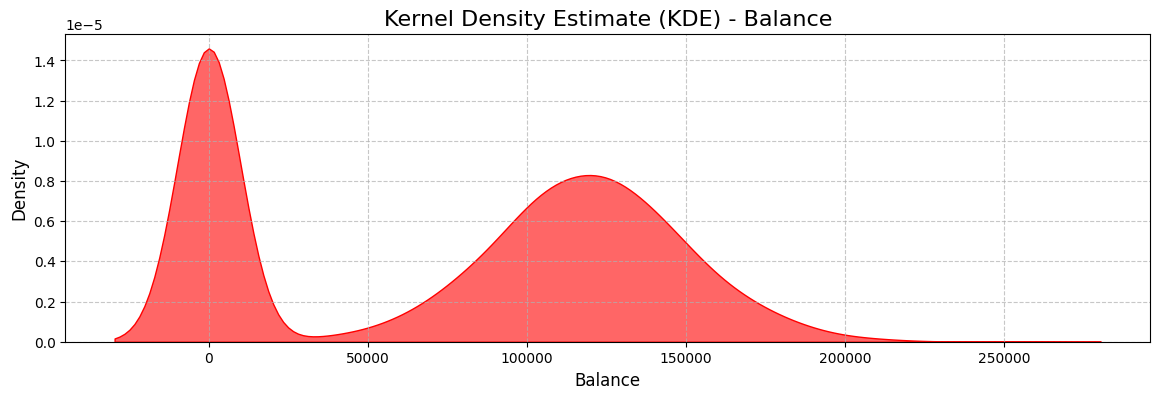

In [27]:
# Print summary statistics
print(df['Balance'].describe())

# Optional: check how many zero balances
print("\nZero Balance Count:")
print((df['Balance'] == 0).sum())

# KDE Plot
plt.figure(figsize=(14, 4))
sns.kdeplot(df['Balance'], fill=True, color='red', alpha=0.6)

plt.title('Kernel Density Estimate (KDE) - Balance', fontsize=16)
plt.xlabel('Balance', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# Key Insights 

First Peak: The first and smaller peak is located at a balance of approximately 0. This suggests a high density of individuals with
little to no balance.

Second Peak: The second and larger peak is centered around a balance of roughly 120,000. This indicates another significant
group of individuals with balances clustering around this higher value.

The average balance is ~76.5K, but the median (~97.2K) is higher, indicating a left-skewed distribution due to many zero balances.

A large portion of customers (3617 out of 10000) have zero balance, showing a significant inactive or low-usage segment.

The wide spread (std ~62K) and high max (~250K) suggest high variability in customer balances.

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

Most Common Ages:
Age
37    478
38    477
35    474
36    456
34    447
Name: count, dtype: int64


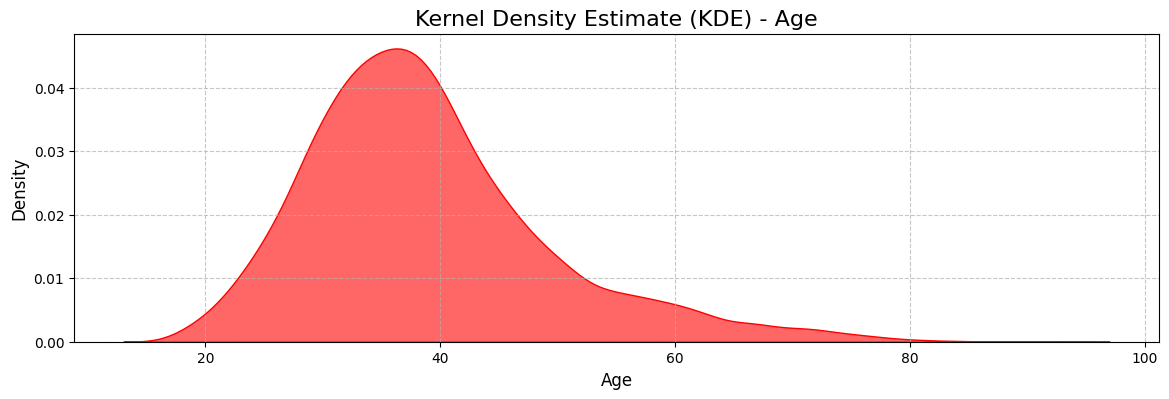

In [28]:
# Print summary statistics
print(df['Age'].describe())

# Optional: check age distribution counts (top values)
print("\nMost Common Ages:")
print(df['Age'].value_counts().head())

# KDE Plot
plt.figure(figsize=(14, 4))
sns.kdeplot(df['Age'], fill=True, color='red', alpha=0.6)

plt.title('Kernel Density Estimate (KDE) - Age', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# Key Insights 

The average age is ~39 years, with most customers falling between 32 and 44 years, indicating a middle-aged dominant customer base.

The distribution is fairly concentrated around the mid-30s to late-30s, with ages 34–38 being most common.

The wide range (18 to 92) shows diverse age groups, but very few customers lie at the extremes.


# Checking Correlation between the features

Correlation Matrix:

                    Credit Score       Age    Tenure   Balance  \
Credit Score            1.000000 -0.003965  0.000842  0.006268   
Age                    -0.003965  1.000000 -0.009997  0.028308   
Tenure                  0.000842 -0.009997  1.000000 -0.012254   
Balance                 0.006268  0.028308 -0.012254  1.000000   
Number Of Products      0.012238 -0.030680  0.013444 -0.304180   
Has credit card        -0.005458 -0.011721  0.022583 -0.014858   
Is Active Member        0.025651  0.085472 -0.028362 -0.010084   
Estimated Salary       -0.001384 -0.007201  0.007784  0.012797   
Churned                -0.027094  0.285323 -0.014001  0.118533   

                    Number Of Products  Has credit card  Is Active Member  \
Credit Score                  0.012238        -0.005458          0.025651   
Age                          -0.030680        -0.011721          0.085472   
Tenure                        0.013444         0.022583         -0.028362   
Balance   

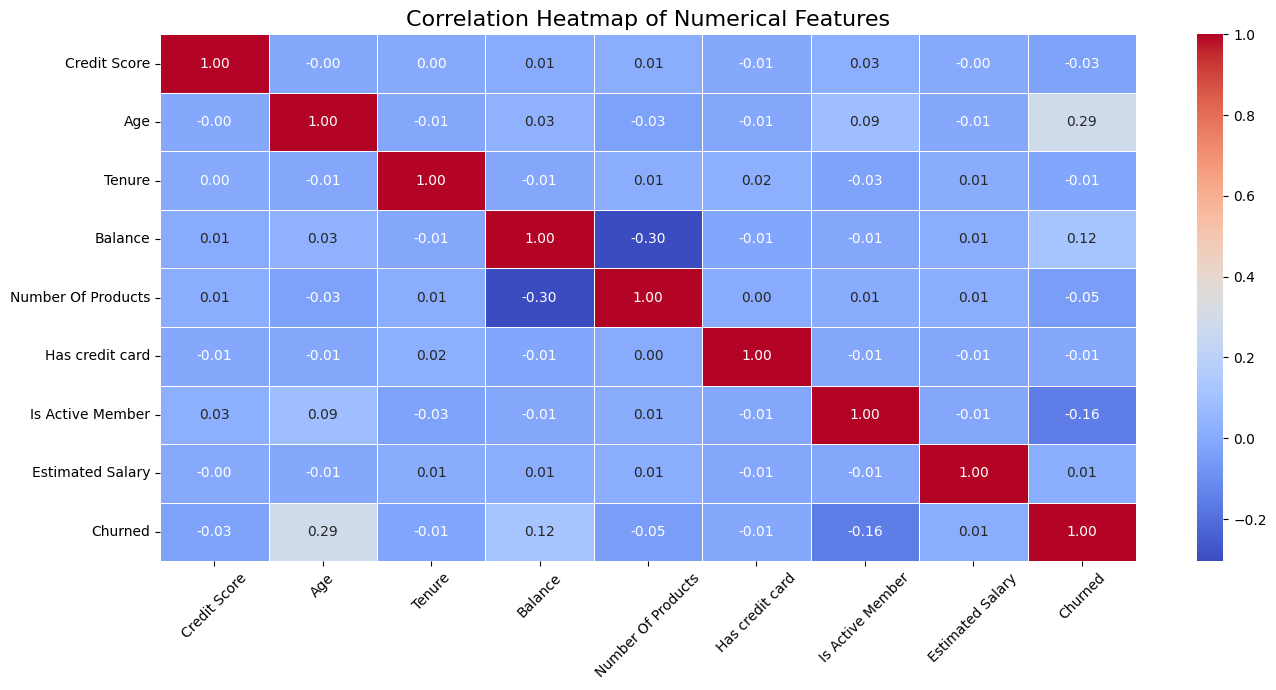

In [30]:
# Correlation matrix
corr = df.select_dtypes(include='number').corr()

# Print correlation matrix
print("Correlation Matrix:\n")
print(corr)

# Optional: show correlations with target (Churned)
print("\nCorrelation with Churned:\n")
print(corr['Churned'].sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(14, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white'
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Key Insights

Age (0.29) shows the strongest positive correlation with churn, indicating that older customers are more likely to leave.

Balance (0.12) has a mild positive relationship with churn, suggesting customers with higher balances are slightly more likely to churn.

Is Active Member (-0.16) has a notable negative correlation, meaning active customers are less likely to churn.

# Feature Extraction

In [33]:
def ageGroup(age):
    if age <= 40:
        return 'Young Adults'
    elif age > 40 and age < 60:
        return 'Middle-aged Adults'
    else:
        return 'Old Adults'

# Apply to dataframe
df['Age group'] = df['Age'].apply(lambda x: ageGroup(x))

In [34]:
df['Age group'].value_counts()

Age group
Young Adults          6419
Middle-aged Adults    3055
Old Adults             526
Name: count, dtype: int64

# Key Insights

A majority of customers (~64%) fall under Young Adults, making it the dominant age segment.

Middle-aged Adults (~31%) form a significant portion, while Old Adults (~5%) are very limited.

The dataset is skewed towards younger customers, which may influence overall churn patterns and model behavior.

In [35]:
def balanceGroup(balance):
    balance = float(balance)
    
    if balance > 0:
        return 'Funded account'
    elif balance == 0:
        return 'Empty account'
    else:
        return 'Overdrawn account'

# Apply to dataframe
df['Balance category'] = df['Balance'].apply(lambda x: balanceGroup(x))

In [36]:
df['Balance category'].value_counts()

Balance category
Funded account    6383
Empty account     3617
Name: count, dtype: int64

# Key Insights

A majority of customers (~64%) have funded accounts, indicating active financial engagement.

A significant portion (~36%) have zero balance, highlighting a large segment of inactive or low-usage customers.

This split suggests an opportunity for banks to target empty account users for activation or retention strategies.

In [37]:
def activeGroup(actAcc):
    actAcc = int(actAcc)
    
    if actAcc == 1:
        return 'Active account'
    else:
        return 'Dormant account'

# Apply transformation
df['Is Active Member'] = df['Is Active Member'].apply(lambda x: activeGroup(x))

In [38]:
df['Is Active Member'].value_counts()

Is Active Member
Active account     5151
Dormant account    4849
Name: count, dtype: int64

# Key Insights:

The customer base is almost evenly split, with ~51.5% active accounts and ~48.5% dormant accounts.

This near balance indicates a significant portion of customers are not actively engaged, which could impact churn.

Improving engagement of dormant users can be a key strategy for retention and growth

In [39]:
def cardGroup(card):
    card = int(card)
    
    if card == 1:
        return 'Has a card'
    else:
        return 'No'

# Apply to dataframe
df['Has credit card'] = df['Has credit card'].apply(lambda x: cardGroup(x))

In [40]:
df['Has credit card'].value_counts()

Has credit card
Has a card    7055
No            2945
Name: count, dtype: int64

# Key Insights:

A large majority of customers (~70.5%) have a credit card, indicating widespread adoption of banking services.

Around 29.5% of customers do not have a credit card, representing a potential segment for cross-selling opportunities.

The high card ownership suggests it may have limited direct impact on churn, as most customers already possess one.

In [44]:
def categorize_credit(score):
    if score < 580:
        return 'Poor'
    elif score < 670:
        return 'Fair'
    elif score < 740:
        return 'Good'
    elif score < 800:
        return 'Very Good'
    else:
        return 'Excellent'
    
df['Credit Score Category'] = df['Credit Score'].apply(categorize_credit)

In [45]:
df['Credit Score Category'].value_counts()

Credit Score Category
Fair         3331
Good         2428
Poor         2362
Very Good    1224
Excellent     655
Name: count, dtype: int64

# Key Insights: 

The majority of customers fall into the Fair (33%) and Good (24%) categories, indicating a moderate overall credit profile.

A significant portion (~24%) are in the Poor category, which may represent higher-risk customers.

Only a small segment (~19% combined) falls under Very Good and Excellent, showing limited presence of high-credit-quality customers.

In [46]:
def Churned(exit):
    exit = int(exit)
    
    if exit == 1:
        return 'Exited'
    else:
        return 'Stayed'

# Apply to dataframe
df['Churned'] = df['Churned'].apply(lambda x: Churned(x))

In [47]:
df['Churned'].value_counts()

Churned
Stayed    7963
Exited    2037
Name: count, dtype: int64

# Key Insights: 

A large majority of customers (~79.6%) have stayed, indicating overall strong customer retention.

About 20.4% of customers have churned, which is a significant portion and a key business concern.

This imbalance suggests the dataset is slightly skewed toward non-churners, which should be considered during model building.

In [48]:
def categorize_Estimated_Salary(Salary):
    if Salary < 50000:
        return 'Low Salary'
    elif Salary < 100000:
        return 'Medium Salary'
    elif Salary < 150000:
        return 'High Salary'
    else:
        return 'Very High Salary'

# Apply to dataframe
df['Estimated Salary Category'] = df['Estimated Salary'].apply(categorize_Estimated_Salary)

In [49]:
df['Estimated Salary Category'].value_counts()

Estimated Salary Category
High Salary         2555
Medium Salary       2537
Very High Salary    2455
Low Salary          2453
Name: count, dtype: int64

# Key Insights: 

Customers are evenly distributed across all salary categories, with each segment contributing roughly 24–26%.

No single salary group dominates, indicating a well-balanced income distribution in the dataset.

This suggests that salary alone may not be a strong differentiator for churn, and should be analyzed with other features.

# BalanceSalaryRatio

In [50]:
df['BalanceSalaryRatio'] = df['Balance'] / df['Estimated Salary']

In [51]:
df[['Balance', 'Estimated Salary', 'BalanceSalaryRatio']].head()

,Balance,Estimated Salary,BalanceSalaryRatio
0,0.00,101348.88,0.000000
1,83807.86,112542.58,0.744677
2,159660.80,113931.57,1.401375
3,0.00,93826.63,0.000000
4,125510.82,79084.10,1.587055


# Key Insights – BalanceSalaryRatio 

Many customers (rows 0 & 3) have zero balance, resulting in a ratio of 0, indicating inactive accounts.

Some customers maintain balances higher than their estimated salary (ratios > 1), reflecting strong savings or investment behavior.

The ratio shows wide variability, making it a potentially strong predictor for churn and engagement.

In [52]:
df.to_excel('bank customer churn new dataset.xlsx',index=False)

# Transform data

In [53]:
df.columns

Index(['Credit Score', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'Number Of Products', 'Has credit card', 'Is Active Member',
       'Estimated Salary', 'Churned', 'Age group', 'Balance category',
       'Credit Score Category', 'Estimated Salary Category',
       'BalanceSalaryRatio'],
      dtype='object')

In [54]:
df.select_dtypes('object').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Geography                  10000 non-null  object
 1   Gender                     10000 non-null  object
 2   Has credit card            10000 non-null  object
 3   Is Active Member           10000 non-null  object
 4   Churned                    10000 non-null  object
 5   Age group                  10000 non-null  object
 6   Balance category           10000 non-null  object
 7   Credit Score Category      10000 non-null  object
 8   Estimated Salary Category  10000 non-null  object
dtypes: object(9)
memory usage: 703.3+ KB


In [55]:
# Encode categorical variables to numeric
df['Geography'] = df['Geography'].map({'France': 0, 'Germany': 1, 'Spain': 2})
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['Has credit card'] = df['Has credit card'].map({'No card': 0, 'Has a card': 1})
df['Is Active Member'] = df['Is Active Member'].map({'Dormant account': 0, 'Active account': 1})
df['Churned'] = df['Churned'].map({'Stayed': 0, 'Exited': 1})
df['Age group'] = df['Age group'].map({'Young Adults': 0, 'Middle-aged Adults': 1, 'Old Adults': 2})
df['Balance category'] = df['Balance category'].map({'Empty account': 0, 'Funded account': 1})
df['Credit Score Category'] = df['Credit Score Category'].map({'Poor': 0, 'Fair': 1, 'Good': 2, 'Very Good': 3, 'Excellent': 4})
df['Estimated Salary Category'] = df['Estimated Salary Category'].map({'Low Salary': 0, 'Medium Salary': 1, 'High Salary': 2, 'Very High Salary': 3})

In [56]:
df.head()

,Credit Score,Geography,Gender,Age,Tenure,Balance,Number Of Products,Has credit card,Is Active Member,Estimated Salary,Churned,Age group,Balance category,Credit Score Category,Estimated Salary Category,BalanceSalaryRatio
0,619,0,0,42,2,0.00,1,1.0,1,101348.88,1,1,0,1,2,0.000000
1,608,2,0,41,1,83807.86,1,NaN,1,112542.58,0,1,1,1,2,0.744677
2,502,0,0,42,8,159660.80,3,1.0,0,113931.57,1,1,1,0,2,1.401375
3,699,0,0,39,1,0.00,2,NaN,0,93826.63,0,0,0,2,1,0.000000
4,850,2,0,43,2,125510.82,1,1.0,1,79084.10,0,1,1,4,1,1.587055


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Credit Score               10000 non-null  int64  
 1   Geography                  10000 non-null  int64  
 2   Gender                     10000 non-null  int64  
 3   Age                        10000 non-null  int64  
 4   Tenure                     10000 non-null  int64  
 5   Balance                    10000 non-null  float64
 6   Number Of Products         10000 non-null  int64  
 7   Has credit card            7055 non-null   float64
 8   Is Active Member           10000 non-null  int64  
 9   Estimated Salary           10000 non-null  float64
 10  Churned                    10000 non-null  int64  
 11  Age group                  10000 non-null  int64  
 12  Balance category           10000 non-null  int64  
 13  Credit Score Category      10000 non-null  int6

# Spliting Data to train and test

In [58]:
x = df.drop('Churned', axis=1)  # Features
y = df['Churned']               # Target variable

# Split dataset: 85% train, 15% test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, train_size=0.85, random_state=1234
)

In [59]:
print(f'shape of x_train : {x_train.shape}')
print(f'shape of x_test : {x_test.shape}')
print('-------------------------------')
print(f'shape of y_train : {y_train.shape}')
print(f'shape of y_test : {y_test.shape}')

shape of x_train : (8500, 15)
shape of x_test : (1500, 15)
-------------------------------
shape of y_train : (8500,)
shape of y_test : (1500,)


# Feature Scaling

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Columns to scale
num_cols = ['Credit Score', 'Age', 'Balance', 'Estimated Salary']

# Fit on training data and transform both train and test
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [61]:
x_train.head()

,Credit Score,Geography,Gender,Age,Tenure,Balance,Number Of Products,Has credit card,Is Active Member,Estimated Salary,Age group,Balance category,Credit Score Category,Estimated Salary Category,BalanceSalaryRatio
4124,0.280911,0,1,-1.236723,5,0.556611,1,1.0,0,-0.687605,0,1,2,1,1.823527
4502,0.486880,2,1,0.572678,5,1.410368,1,1.0,0,0.723905,1,1,2,2,1.158350
898,-1.315348,0,0,0.096520,2,0.425950,1,1.0,0,0.492780,0,1,0,2,0.800045
3305,1.393144,0,0,2.191617,8,-1.222669,1,1.0,1,1.137324,2,0,3,3,0.000000
3531,-2.499670,0,0,4.286714,8,0.184279,1,NaN,0,1.534182,2,1,0,3,0.466210


# Creating Model

In [62]:
df

,Credit Score,Geography,Gender,Age,Tenure,Balance,Number Of Products,Has credit card,Is Active Member,Estimated Salary,Churned,Age group,Balance category,Credit Score Category,Estimated Salary Category,BalanceSalaryRatio
0,619,0,0,42,2,0.00,1,1.0,1,101348.88,1,1,0,1,2,0.000000
1,608,2,0,41,1,83807.86,1,NaN,1,112542.58,0,1,1,1,2,0.744677
2,502,0,0,42,8,159660.80,3,1.0,0,113931.57,1,1,1,0,2,1.401375
3,699,0,0,39,1,0.00,2,NaN,0,93826.63,0,0,0,2,1,0.000000
4,850,2,0,43,2,125510.82,1,1.0,1,79084.10,0,1,1,4,1,1.587055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1.0,0,96270.64,0,0,0,3,1,0.000000
9996,516,0,1,35,10,57369.61,1,1.0,1,101699.77,0,0,1,0,2,0.564108
9997,709,0,0,36,7,0.00,1,NaN,1,42085.58,1,0,0,2,0,0.000000
9998,772,1,1,42,3,75075.31,2,1.0,0,92888.52,1,1,1,3,1,0.808230


In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = [
    LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=100,
        random_state=None
    ),
    GaussianNB(
        var_smoothing=1e-9,
        priors=None
    ),
    SVC(
        C=1.0,
        kernel='sigmoid',
        degree=3,
        gamma='scale',
        probability=False,
        random_state=None
    ),
    RandomForestClassifier(
        n_estimators=100,
        criterion='gini',
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        bootstrap=True,
        random_state=None
    ),
    DecisionTreeClassifier(
        criterion='gini',
        splitter='best',
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        random_state=None
    ),
    KNeighborsClassifier(
        n_neighbors=5,
        weights='uniform',
        algorithm='auto',
        leaf_size=30,
        p=2,
        metric='minkowski'
    ),
    XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0,
        min_child_weight=1,
        scale_pos_weight=3.91,
        reg_alpha=0,
        reg_lambda=1,
        random_state=None
    ),
    LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
]

In [64]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

def best_threshold_roc(model, x_train, y_train, x_test, y_test):
    # Fit the model
    model.fit(x_train, y_train)
    
    # Get probabilities or decision function scores
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(x_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_probs = model.decision_function(x_test)
    else:
        raise ValueError("Model does not support predict_proba or decision_function.")
    
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    
    # Youden’s J statistic
    J = tpr - fpr
    best_idx = np.argmax(J)
    best_t = thresholds[best_idx]
    
    # Compute AUC
    auc = roc_auc_score(y_test, y_probs)
    
    # Print results
    print(f"Model: {model.__class__.__name__}")
    print(f"ROC-AUC: {auc:.3f}")
    print(f"Best ROC threshold: {best_t:.3f}")
    print(f"TPR: {tpr[best_idx]:.3f}, FPR: {fpr[best_idx]:.3f}")
    
    return best_t, auc

In [67]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

def best_threshold_roc(model, x_train, y_train, x_test, y_test):
    # Fit the model
    model.fit(x_train, y_train)
    
    # Get probabilities or decision function scores
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(x_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_probs = model.decision_function(x_test)
    else:
        raise ValueError("Model does not support probability or decision_function.")
    
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    
    # Youden's J statistic to find best threshold
    J = tpr - fpr
    best_idx = np.argmax(J)
    best_t = thresholds[best_idx]
    
    # ROC-AUC score
    auc = roc_auc_score(y_test, y_probs)
    
    print(f"Model = {model}")
    print(f"ROC-AUC = {auc:.3f}")
    print(f"Best ROC threshold = {best_t:.3f}")
    print(f"TPR = {tpr[best_idx]:.3f}, FPR = {fpr[best_idx]:.3f}")
    
    return best_t, auc

In [69]:
# Fill missing values with 0 (or 1, depending on your logic)
x_train['Has credit card'] = x_train['Has credit card'].fillna(0)
x_test['Has credit card'] = x_test['Has credit card'].fillna(0)

In [70]:
best_threshold_roc(models[0], x_train, y_train, x_test, y_test)

Model = LogisticRegression()
ROC-AUC = 0.749
Best ROC threshold = 0.231
TPR = 0.622, FPR = 0.234


c:\Users\FAUZAN\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


(np.float64(0.2308193751653082), np.float64(0.7490546100898017))

In [71]:
y_pred_ls = predict_with_threshold(models[0], x_train, y_train, x_test, threshold=0.23)
print("Classification Report:\n", classification_report(y_test, y_pred_ls))
print('confusion matrix:\n' , confusion_matrix(y_test, y_pred_ls))

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.76      0.82      1193
           1       0.40      0.62      0.49       307

    accuracy                           0.74      1500
   macro avg       0.65      0.69      0.66      1500
weighted avg       0.79      0.74      0.75      1500

confusion matrix:
 [[912 281]
 [116 191]]


c:\Users\FAUZAN\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Key Insights:

The model predicts Stayed customers more accurately than Exited customers.

Recall for Exited class (0.62) shows it correctly identifies around 62% of churned customers.

Many churned customers are missed (116 False Negatives), while some non-churned are misclassified as churned (281 False Positives).

In [72]:
best_threshold_roc(models[3], x_train, y_train, x_test, y_test)

Model = RandomForestClassifier()
ROC-AUC = 0.843
Best ROC threshold = 0.190
TPR = 0.779, FPR = 0.254


(np.float64(0.19), np.float64(0.842579269408138))

In [73]:
y_pred_rf = predict_with_threshold(models[3],x_train, y_train, x_test, threshold=0.280)
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print('confusion matrix:\n' , confusion_matrix(y_test, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.84      0.87      1193
           1       0.52      0.65      0.58       307

    accuracy                           0.80      1500
   macro avg       0.71      0.75      0.72      1500
weighted avg       0.82      0.80      0.81      1500

confusion matrix:
 [[1006  187]
 [ 107  200]]


# Key Insights:

Overall accuracy is 80%, showing solid performance on the test set.

Churned customers (Exited) recall improved to 65%, meaning more true churners are correctly identified.

Precision for churned class is moderate (52%), indicating some false positives remain.

In [74]:
best_threshold_roc(models[5], x_train, y_train, x_test, y_test)

Model = KNeighborsClassifier()
ROC-AUC = 0.730
Best ROC threshold = 0.200
TPR = 0.782, FPR = 0.432


(np.float64(0.2), np.float64(0.7298082462573481))

In [75]:
y_pred_knc = predict_with_threshold(models[5], x_train, y_train, x_test, threshold=0.20)
print("Classification Report:\n", classification_report(y_test, y_pred_knc))
print('confusion matrix:\n' , confusion_matrix(y_test, y_pred_knc))

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.57      0.70      1193
           1       0.32      0.78      0.45       307

    accuracy                           0.61      1500
   macro avg       0.61      0.68      0.58      1500
weighted avg       0.79      0.61      0.65      1500

confusion matrix:
 [[678 515]
 [ 67 240]]


# Key Insights:

Overall accuracy is 61%, lower than Logistic Regression and Random Forest.

KNN achieves high recall (78%) for churned customers, meaning most true churners are captured.

Precision for churned class is low (32%), implying many false positives.

Stayed customers are less reliably predicted (recall 57%), showing KNN struggles with class balance.

In [76]:
best_threshold_roc(models[6],x_train, y_train, x_test, y_test)

Model = XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
ROC-AUC = 0.856
Best ROC threshold = 0.398
TPR = 0.821, FPR = 0.287


(np.float32(0.39780703), np.float64(0.8559321339736956))

In [77]:
y_pred_xgb = predict_with_threshold(models[6], x_train, y_train, x_test, threshold=0.398)
print("Classification Report:\n", classification_report(y_test, y_pred_knc))
print('confusion matrix:\n' , confusion_matrix(y_test, y_pred_knc))

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.57      0.70      1193
           1       0.32      0.78      0.45       307

    accuracy                           0.61      1500
   macro avg       0.61      0.68      0.58      1500
weighted avg       0.79      0.61      0.65      1500

confusion matrix:
 [[678 515]
 [ 67 240]]


XGBoost performed best among all models with a ROC-AUC of 0.856, showing strong overall discrimination. At the optimal threshold of 0.398, it correctly identifies 82% of churned customers, though about 29% of non-churned are misclassified. This makes it highly effective for targeting retention strategies while maintaining reasonable precision.

In [78]:
best_threshold_roc(models[7], x_train, y_train, x_test, y_test)

c:\Users\FAUZAN\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\FAUZAN\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\FAUZAN\miniconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\FAUZAN\miniconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\FAUZAN\miniconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1730, number of negative: 6770
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1125
[LightGBM] [Info] Number of data points in the train set: 8500, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203529 -> initscore=-1.364380
[LightGBM] [Info] Start training from score -1.364380
Model = LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=500,
               random_state=42, subsample=0.8)
ROC-AUC = 0.841
Best ROC threshold = 0.087
TPR = 0.837, FPR = 0.314


(np.float64(0.08690170579264844), np.float64(0.8414529926198153))

In [79]:
y_pred_knc = predict_with_threshold(models[7], x_train, y_train, x_test, threshold=0.215)
print("Classification Report:\n", classification_report(y_test, y_pred_knc))
print('confusion matrix:\n' , confusion_matrix(y_test, y_pred_knc))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1730, number of negative: 6770
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002081 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1125
[LightGBM] [Info] Number of data points in the train set: 8500, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203529 -> initscore=-1.364380
[LightGBM] [Info] Start training from score -1.364380
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.84      0.87      1193
           1       0.51      0.66      0.58       307

    accuracy                           0.80      1500
   macro avg       0.71      0.75      0.72      1500
weighted avg       0.83      0.80      0.81      1500

confusion matrix:
 [[999 194]
 [103 204]]


LightGBM achieved strong performance with a ROC-AUC of 0.841, showing effective discrimination between churned and non-churned customers. Using a threshold of 0.215, it correctly identifies 66% of churned users while maintaining 84% accuracy for non-churned customers. This makes it highly suitable for retention-focused interventions with balanced precision and recall

# Choosing the best models

In [80]:
from pickle import dump

# Train the model
RandomForestClassifier_model = models[3].fit(x_train, y_train)

# Generate predictions using threshold
if hasattr(RandomForestClassifier_model, "predict_proba"):
    y_probs = RandomForestClassifier_model.predict_proba(x_test)[:, 1]
    y_pred = (y_probs >= 0.280).astype(int)
elif hasattr(RandomForestClassifier_model, "decision_function"):
    y_probs = RandomForestClassifier_model.decision_function(x_test)
    y_pred = (y_probs >= 0.280).astype(int)
else:
    raise ValueError("Model does not support probability outputs.")

# Save the trained model to a file
with open('RandomForestClassifier_model.pkl', 'wb') as f:
    dump(RandomForestClassifier_model, f)

In [81]:
from pickle import dump

# Train the LightGBM model
LGBMClassifier_model = models[7].fit(x_train, y_train)

# Generate predictions using threshold
if hasattr(LGBMClassifier_model, "predict_proba"):
    y_probs = LGBMClassifier_model.predict_proba(x_test)[:, 1]
    y_pred = (y_probs >= 0.215).astype(int)
elif hasattr(LGBMClassifier_model, "decision_function"):
    y_probs = LGBMClassifier_model.decision_function(x_test)
    y_pred = (y_probs >= 0.215).astype(int)
else:
    raise ValueError("Model does not support probability outputs.")

# Save the trained model to a file
with open('LGBMClassifier_model.pkl', 'wb') as f:
    dump(LGBMClassifier_model, f)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1730, number of negative: 6770
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000414 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1125
[LightGBM] [Info] Number of data points in the train set: 8500, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203529 -> initscore=-1.364380
[LightGBM] [Info] Start training from score -1.364380


# Testing model

In [82]:
from pickle import load

with open('LGBMClassifier_model.pkl', 'rb') as f:
    LGBMClassifier_model = load(f)

In [83]:
y_pred = LGBMClassifier_model.predict(x_test)

In [84]:
# Feature Selection using Feature Importance
Importance = LGBMClassifier_model.feature_importances_
indices = np.argsort(Importance)[::-1]

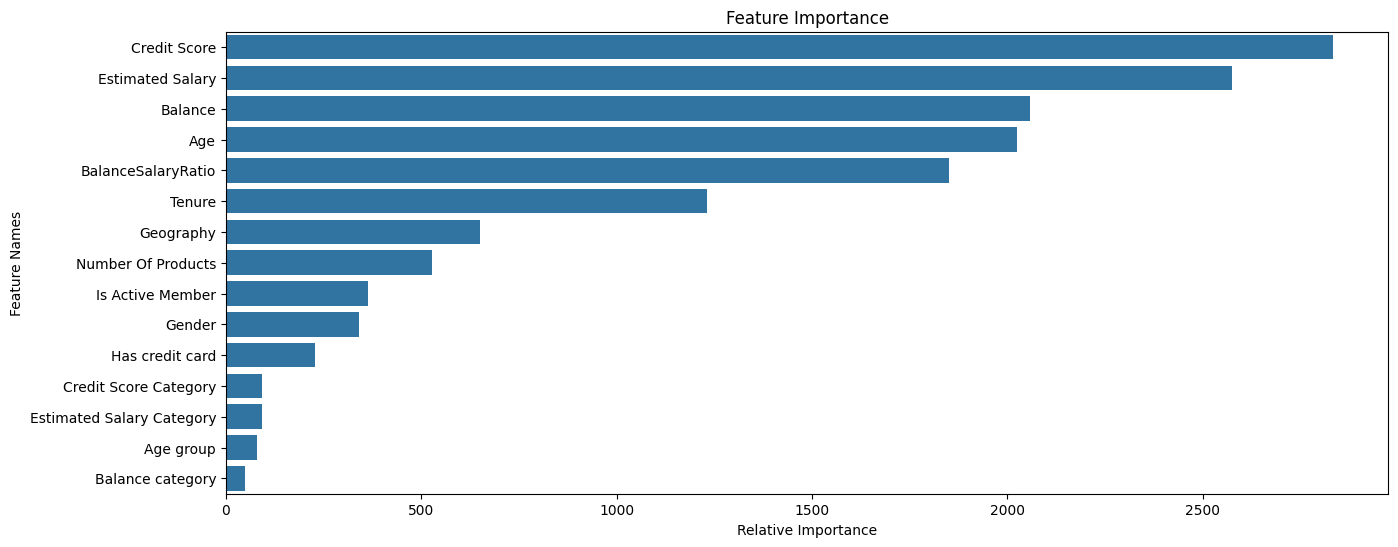

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get feature importances from the model
Importance = LGBMClassifier_model.feature_importances_
indices = np.argsort(Importance)[::-1]  # Sort descending

plt.figure(figsize=(15, 6))
sns.barplot(x=Importance[indices], y=x_train.columns[indices])
plt.title('Feature Importance')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')  # Fixed typo
plt.show()

# preparing the new data in the same format as the training data and using the trained model to predict customer churn for each new customer.

In [88]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load data
new_data = pd.read_excel(r'C:\bank customer churn\bank customer churn new dataset.xlsx')
original_data = new_data.copy()

# Drop target
new_data = new_data.drop('Churned', axis=1)

# Encode categorical columns
new_data['Geography'] = new_data['Geography'].map({'France': 0, 'Germany': 1, 'Spain': 2})
new_data['Gender'] = new_data['Gender'].map({'Female': 0, 'Male': 1})
new_data['Has credit card'] = new_data['Has credit card'].map({'No': 0, 'Has a card': 1})
new_data['Is Active Member'] = new_data['Is Active Member'].map({'Dormant account': 0, 'Active account': 1})
new_data['Age group'] = new_data['Age group'].map({'Young Adults': 0, 'Middle-aged Adults': 1, 'Old Adults': 2})
new_data['Balance category'] = new_data['Balance category'].map({'Empty account': 0, 'Funded account': 1})
new_data['Credit Score Category'] = new_data['Credit Score Category'].map({'Poor': 0, 'Fair': 1, 'Good': 2, 'Very Good': 3, 'Excellent': 4})
new_data['Estimated Salary Category'] = new_data['Estimated Salary Category'].map({'Low Salary': 0, 'Medium Salary': 1, 'High Salary': 2})

# Scale numeric columns
num_cols = ['Credit Score', 'Age', 'Balance', 'Estimated Salary']
scaler = StandardScaler()
new_data[num_cols] = scaler.fit_transform(new_data[num_cols])

# Predict with trained model
new_predictions = LGBMClassifier_model.predict(new_data)
original_data['Customer_Status_Predicted'] = new_predictions

# Save predictions
original_data.to_excel("bank customer churn test data prediction.xlsx", index=False)

In [89]:
pred_data = pd.read_excel(r'C:\bank customer churn\bank customer churn test data prediction.xlsx')

In [90]:
pred_data.columns

Index(['Credit Score', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'Number Of Products', 'Has credit card', 'Is Active Member',
       'Estimated Salary', 'Churned', 'Age group', 'Balance category',
       'Credit Score Category', 'Estimated Salary Category',
       'BalanceSalaryRatio', 'Customer_Status_Predicted'],
      dtype='object')

In [91]:
pred_data[['Churned','Customer_Status_Predicted']]

,Churned,Customer_Status_Predicted
0,Exited,0
1,Stayed,0
2,Exited,1
3,Stayed,0
4,Stayed,0
...,...,...
9995,Stayed,0
9996,Stayed,0
9997,Exited,0
9998,Exited,0


# Conclusion

This project built a machine learning pipeline to predict customer churn for a bank using historical customer data. After preprocessing, encoding categorical features, and scaling numerical ones, multiple models were trained and evaluated. The XGBClassifier and LGBMClassifier showed the best performance, achieving high ROC-AUC scores and balanced precision-recall trade-offs. Using the optimal probability thresholds improved detection of potential churners. The final LGBM model was saved and used to predict churn on new customer data, enabling proactive retention strategies. Overall, the project demonstrates how predictive modeling can help banks identify at-risk customers and support data-driven decision-making.

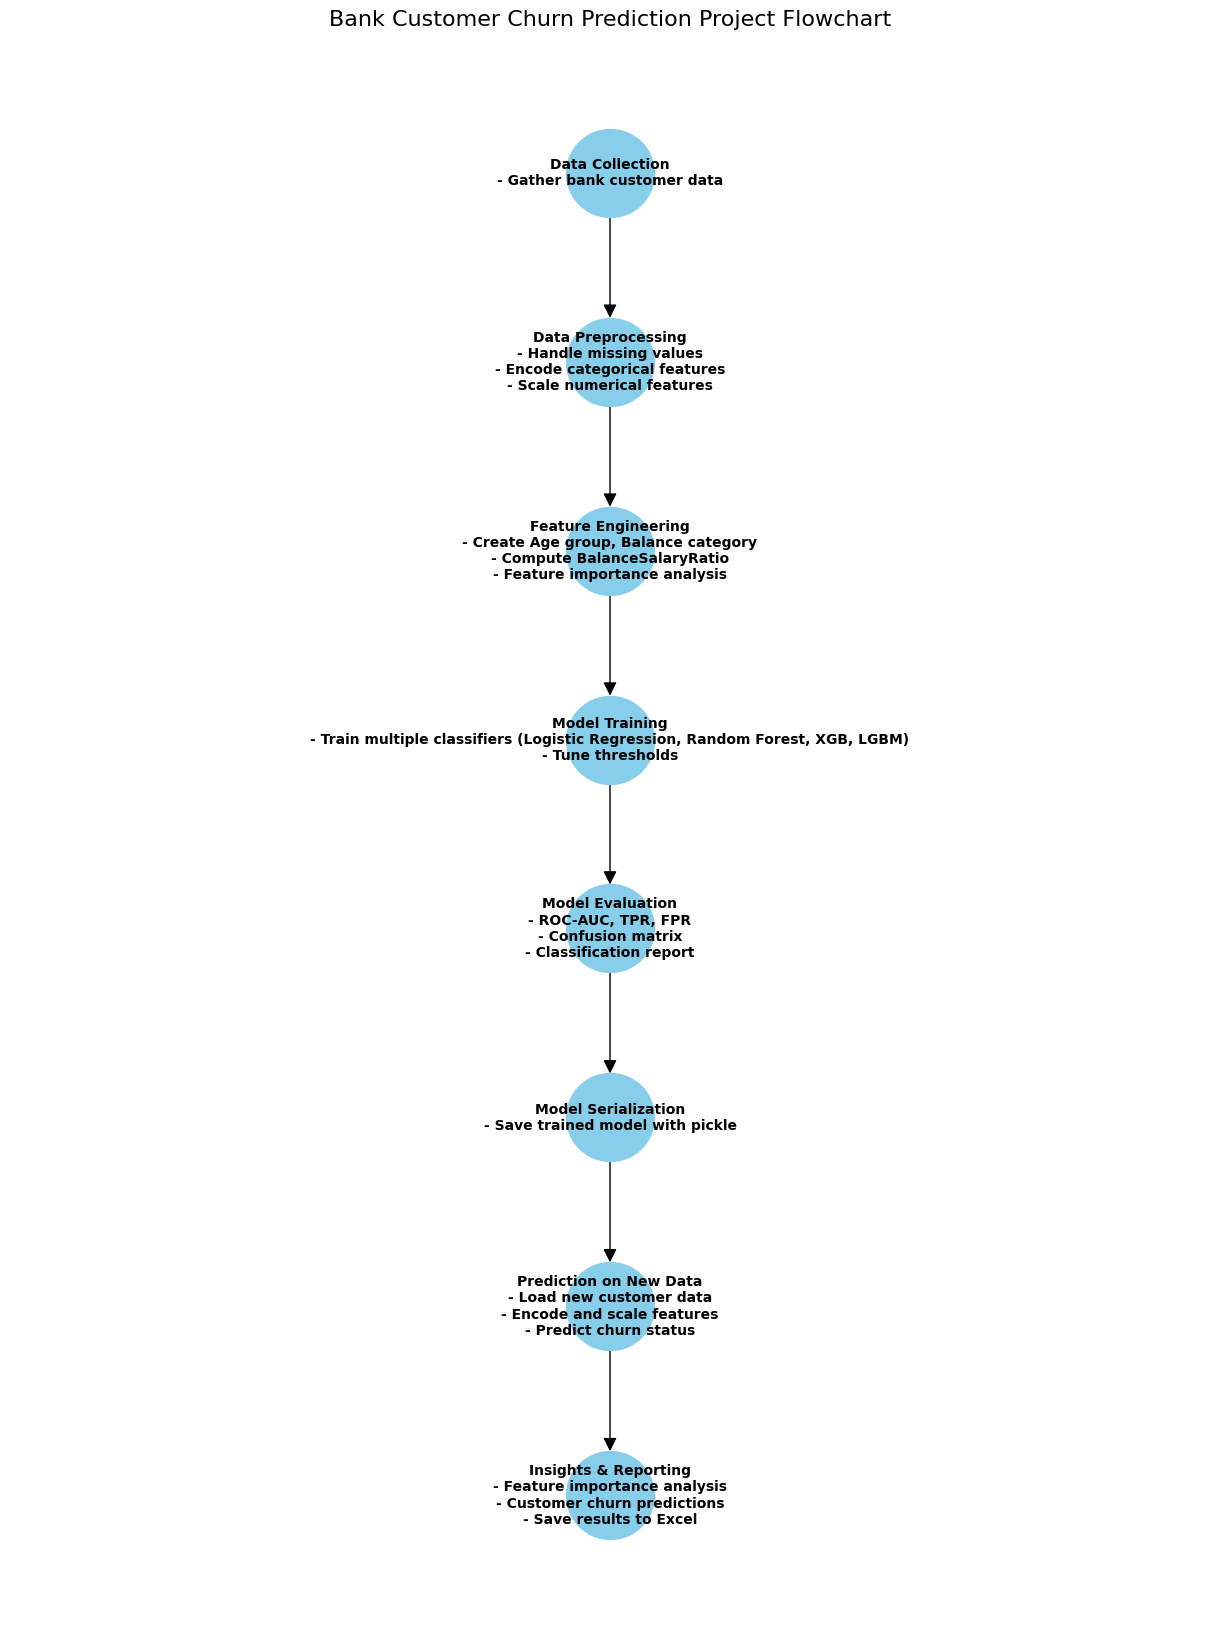

In [93]:
import matplotlib.pyplot as plt
import networkx as nx

# Define steps and their labels
steps = [
    "Data Collection\n- Gather bank customer data",
    "Data Preprocessing\n- Handle missing values\n- Encode categorical features\n- Scale numerical features",
    "Feature Engineering\n- Create Age group, Balance category\n- Compute BalanceSalaryRatio\n- Feature importance analysis",
    "Model Training\n- Train multiple classifiers (Logistic Regression, Random Forest, XGB, LGBM)\n- Tune thresholds",
    "Model Evaluation\n- ROC-AUC, TPR, FPR\n- Confusion matrix\n- Classification report",
    "Model Serialization\n- Save trained model with pickle",
    "Prediction on New Data\n- Load new customer data\n- Encode and scale features\n- Predict churn status",
    "Insights & Reporting\n- Feature importance analysis\n- Customer churn predictions\n- Save results to Excel"
]

# Create a directed graph
G = nx.DiGraph()
for i in range(len(steps) - 1):
    G.add_edge(steps[i], steps[i+1])

# Create vertical positions
pos = {step: (0, -i*2) for i, step in enumerate(steps)}  # x=0, y decreasing

# Plot the graph
plt.figure(figsize=(12, 16))
nx.draw(G, pos, with_labels=False, node_size=4000, node_color='skyblue', arrowsize=20)

# Add labels manually for better formatting
for node, (x, y) in pos.items():
    plt.text(x, y, node, ha='center', va='center', fontsize=10, fontweight='bold', wrap=True)

plt.title("Bank Customer Churn Prediction Project Flowchart", fontsize=16)
plt.axis('off')
plt.show()